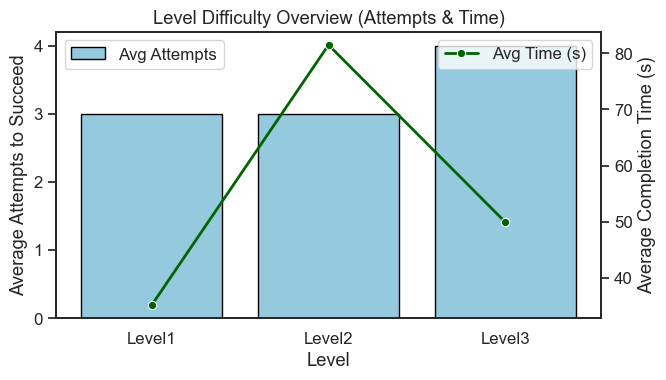


 Level Summary:


,level,avg_attempts,avg_time,n_runs
0,Level1,3,35.1,67
1,Level2,3,81.5,49
2,Level3,4,49.9,21


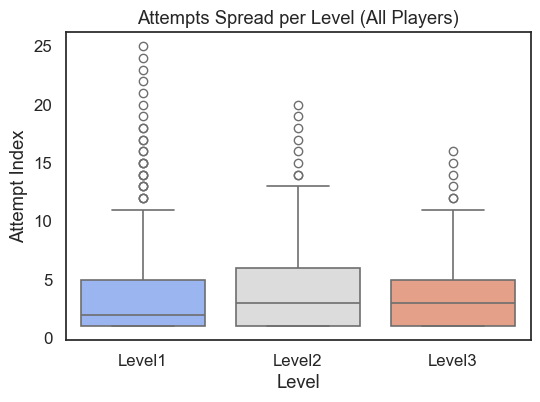

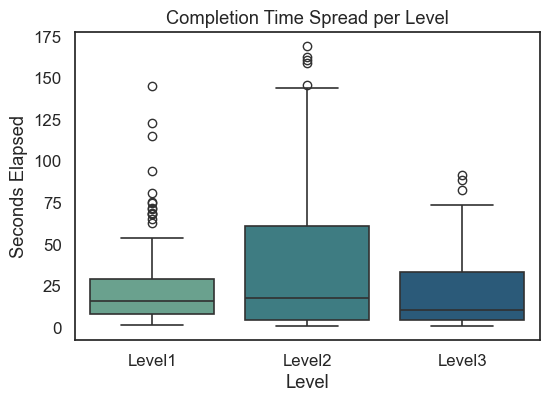

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set(style="white", font_scale=1.1)

file_path = r"metric1_beta.csv"
df = pd.read_csv(file_path)

df.columns = [c.strip().replace(" ", "_") for c in df.columns]
df["attemptIndex"] = df["attemptIndex"].astype(int)
df["secondsElapsed"] = df["secondsElapsed"].astype(float)
df = df[df["eventType"] == "RunEnd"]

success_df = df[df["result"] == "success"].copy()

# ==============================
# 1. Level Difficulty Overview
# ==============================
summary = (
    success_df.groupby("level")
    .agg(avg_attempts=("attemptIndex", "mean"),
         avg_time=("secondsElapsed", "mean"),
         n_runs=("attemptIndex", "count"))
    .reset_index()
)

summary["avg_attempts"] = summary["avg_attempts"].round(0).astype(int)
summary["avg_time"] = summary["avg_time"].round(1)

# --- Plot ---
fig, ax1 = plt.subplots(figsize=(7, 4))
sns.barplot(x="level", y="avg_attempts", data=summary, color="skyblue", ax=ax1, label="Avg Attempts", edgecolor="black")
ax1.set_ylabel("Average Attempts to Succeed")
ax1.set_xlabel("Level")
ax1.set_title("Level Difficulty Overview (Attempts & Time)")
ax1.legend(loc="upper left")

ax2 = ax1.twinx()
sns.lineplot(x="level", y="avg_time", data=summary, color="darkgreen", marker="o", linewidth=2, ax=ax2, label="Avg Time (s)")
ax2.set_ylabel("Average Completion Time (s)")
ax2.legend(loc="upper right")

ax1.grid(False)
ax2.grid(False)

plt.tight_layout()
plt.show()

print("\n Level Summary:")
display(summary)


# ==============================
# 2. Attempts Distribution (Frustration Spread)
# ==============================
plt.figure(figsize=(6,4))
sns.boxplot(x="level", y="attemptIndex", data=df, palette="coolwarm", linewidth=1.2)
plt.title("Attempts Spread per Level (All Players)")
plt.xlabel("Level")
plt.ylabel("Attempt Index")
plt.grid(False)
plt.show()

# ==============================
# 3. Completion Time Spread
# ==============================
plt.figure(figsize=(6,4))
sns.boxplot(x="level", y="secondsElapsed", data=df, palette="crest", linewidth=1.2)
plt.title("Completion Time Spread per Level")
plt.xlabel("Level")
plt.ylabel("Seconds Elapsed")
plt.grid(False)
plt.show()
